In [28]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso
)

from sklearn.preprocessing import PolynomialFeatures
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import RandomForestRegressor

from sklearn.svm import SVR

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [3]:
df = pd.read_csv("E:\ml assignment\diabetes_dataset_prediction\data\diabetes_cleaned.csv")

df.head()

<>:1: SyntaxWarning: invalid escape sequence '\m'
<>:1: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Samya\AppData\Local\Temp\ipykernel_23180\2638332900.py:1: SyntaxWarning: invalid escape sequence '\m'
  df = pd.read_csv("E:\ml assignment\diabetes_dataset_prediction\data\diabetes_cleaned.csv")


,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,0,1.700840,0,1,1,-0.317475,0.994563,0.043554,0
1,0,0.543372,0,0,0,0.007649,0.994563,-1.423096,0
2,1,-0.614096,0,0,1,0.007649,0.155970,0.483549,0
3,0,-0.257952,0,0,5,-0.583069,-0.496269,0.410216,0
4,1,1.522768,1,1,5,-1.088309,-0.682623,0.410216,0


In [4]:
X = df.drop(columns=["bmi"])

y = df["bmi"]

In [39]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

SIMPLE LINEAR REGRESION

In [33]:
X_L = df[["age"]]

y_L = df["bmi"]

In [36]:
X_L_train, X_L_test, y_L_train, y_L_test = train_test_split(
    X_L,
    y_L,
    test_size=0.2,
    random_state=42
)

In [37]:
lr = LinearRegression()

lr.fit(X_L_train, y_L_train)

y_L_pred = lr.predict(X_L_test)

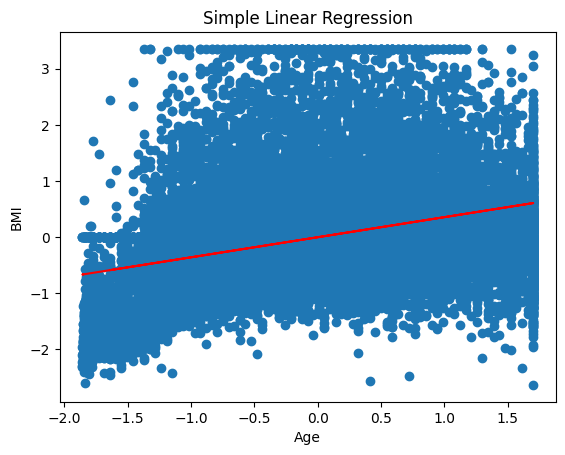

In [38]:
plt.scatter(X_L_test, y_L_test)

plt.plot(X_L_test, y_L_pred, color='red')

plt.xlabel("Age")

plt.ylabel("BMI")

plt.title("Simple Linear Regression")

plt.show()

In [41]:
slr_rmse = np.sqrt(
    mean_squared_error(y_test, y_L_pred)
)

slr_mae = mean_absolute_error(
    y_test,
    y_L_pred
)
print("MAE : " , slr_mae)
print("RMSE : " , slr_rmse)

MAE :  0.6976355201995411
RMSE :  0.9386863391221788


MULTIPLE LINEAR REGRESSION

In [6]:
# LINEAR REGRESSION 

lr = LinearRegression()

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

In [7]:
lr_r2 = r2_score(y_test, y_pred_lr)

lr_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lr)
)

lr_mae = mean_absolute_error(
    y_test,
    y_pred_lr
)

print("R2 Score:", lr_r2)
print("RMSE:", lr_rmse)
print("MAE:", lr_mae)

R2 Score: 0.14380701707715005
RMSE: 0.9251638346343681
MAE: 0.6897364002595304


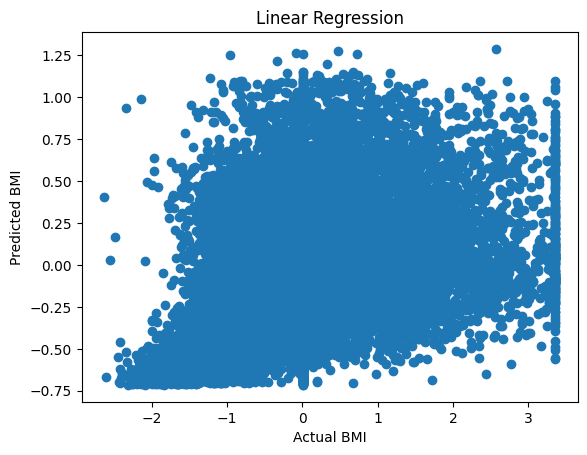

In [8]:
plt.scatter(y_test, y_pred_lr)

plt.xlabel("Actual BMI")
plt.ylabel("Predicted BMI")

plt.title("Linear Regression")

plt.show()

POLYNOMIAL REGRESSION

In [29]:
degrees = [1, 2, 3, 4]

poly_scores = []

for d in degrees:

    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train)

    X_test_poly = poly.transform(X_test)

    model = LinearRegression()

    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)

    r2 = r2_score(y_test, y_pred)

    poly_scores.append(r2)

    print("Degree:", d, "R2:", r2)

Degree: 1 R2: 0.14380701707715005
Degree: 2 R2: 0.26936457270308223
Degree: 3 R2: 0.27235184841447035
Degree: 4 R2: 0.2718175974302225


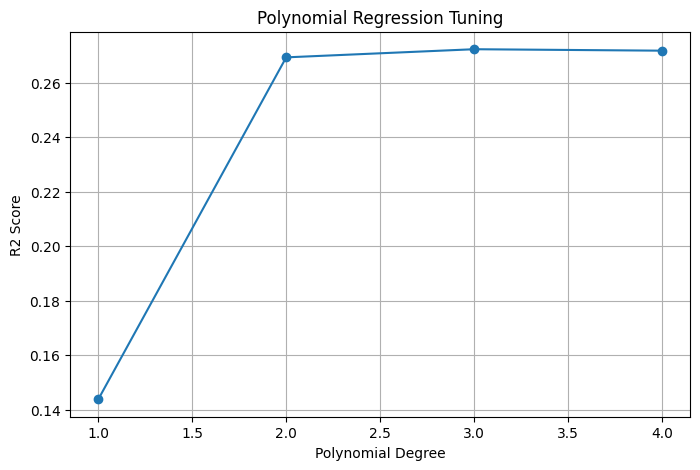

In [30]:
plt.figure(figsize=(8,5))

plt.plot(
    degrees,
    poly_scores,
    marker='o'
)

plt.xlabel("Polynomial Degree")

plt.ylabel("R2 Score")

plt.title("Polynomial Regression Tuning")

plt.grid(True)

plt.show()

In [31]:
best_degree = degrees[
    np.argmax(poly_scores)
]

print("Best Degree:", best_degree)

Best Degree: 3


In [32]:
# BEST POLYNOMIAL MODEL 
best_poly = PolynomialFeatures(
    degree=best_degree
)

X_train_poly = best_poly.fit_transform(X_train)

X_test_poly = best_poly.transform(X_test)

final_poly_model = LinearRegression()

final_poly_model.fit(
    X_train_poly,
    y_train
)

y_pred_poly = final_poly_model.predict(
    X_test_poly
)

poly_r2 = r2_score(
    y_test,
    y_pred_poly
)

print(poly_r2)

0.27235184841447035


In [47]:
poly_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_poly)
)

poly_mae = mean_absolute_error(
    y_test,
    y_pred_poly
)
print("MAE : ",poly_mae)
print("RMSE : ",poly_rmse)

MAE :  0.6262990598487933
RMSE :  0.852890998151393


RIDGE REGRESSION

In [17]:
alpha_values = [0.01, 0.1, 1, 10, 100]

ridge_scores = []

for a in alpha_values:

    ridge = Ridge(alpha=a)

    ridge.fit(X_train, y_train)

    y_pred = ridge.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    ridge_scores.append(r2)

    print("Alpha:", a, "R2:", r2)

Alpha: 0.01 R2: 0.1438070211405318
Alpha: 0.1 R2: 0.143807057701693
Alpha: 1 R2: 0.1438074223956961
Alpha: 10 R2: 0.14381097808808463
Alpha: 100 R2: 0.1438379005175665


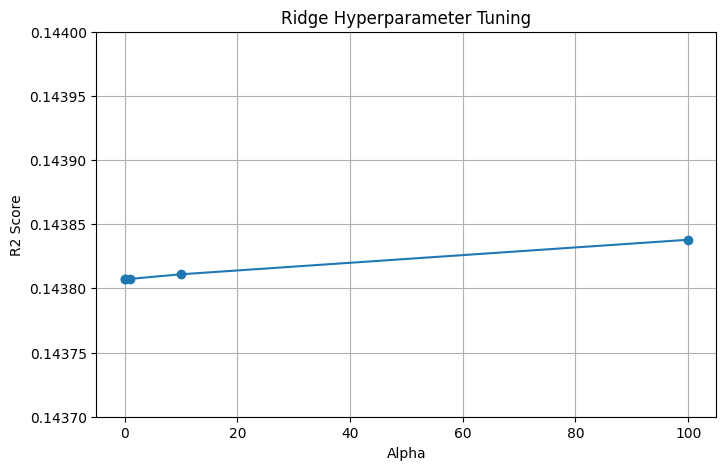

In [19]:
plt.figure(figsize=(8,5))

plt.plot(
    alpha_values,
    ridge_scores,
    marker='o'
)

plt.xlabel("Alpha")

plt.ylabel("R2 Score")

plt.title("Ridge Hyperparameter Tuning")

plt.ylim(0.1437, 0.1440)

plt.grid(True)

plt.show()

In [10]:
best_alpha_ridge = alpha_values[
    np.argmax(ridge_scores)
]

print(best_alpha_ridge)

100


In [11]:
best_ridge = Ridge(
    alpha=best_alpha_ridge
)

best_ridge.fit(X_train, y_train)

y_pred_ridge = best_ridge.predict(X_test)

ridge_r2 = r2_score(
    y_test,
    y_pred_ridge
)

print(ridge_r2)

0.1438379005175665


In [45]:
ridge_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_ridge)
)

ridge_mae = mean_absolute_error(
    y_test,
    y_pred_ridge
)
print("MAE : ",ridge_mae)
print("RMSE : ",ridge_rmse)

MAE :  0.6896612137340203
RMSE :  0.9251471488518449


LASSO REGRESSION 

In [48]:
alpha_values = [0.001, 0.01, 0.1, 1]

lasso_scores = []

for a in alpha_values:

    lasso = Lasso(alpha=a)

    lasso.fit(X_train, y_train)

    y_pred_lasso = lasso.predict(X_test)

    r2 = r2_score(y_test, y_pred_lasso)

    lasso_scores.append(r2)

    print("Alpha:", a, "R2:", r2)

Alpha: 0.001 R2: 0.14388425750336975
Alpha: 0.01 R2: 0.14108813052740632
Alpha: 0.1 R2: 0.11724684206821412
Alpha: 1 R2: -0.00016914032390902278


In [63]:
best_alpha_lasso = alpha_values[
    np.argmax(lasso_scores)
]

print(best_alpha_lasso)

0.001


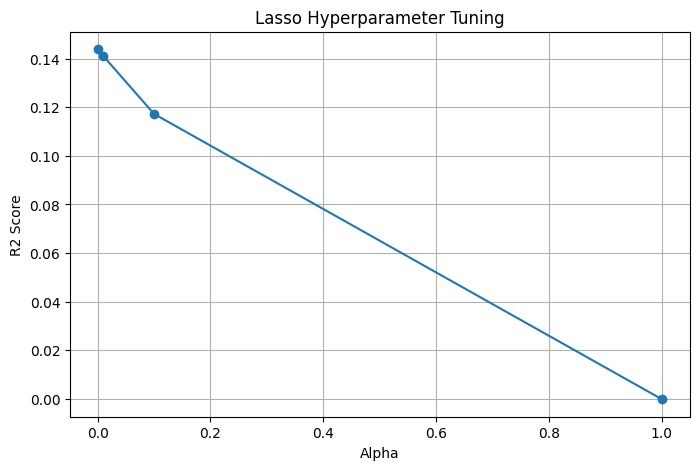

In [22]:
plt.figure(figsize=(8,5))

plt.plot(
    alpha_values,
    lasso_scores,
    marker='o'
)

plt.xlabel("Alpha")

plt.ylabel("R2 Score")

plt.title("Lasso Hyperparameter Tuning")

plt.grid(True)

plt.show()

In [50]:
lasso_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_lasso)
)

lasso_mae = mean_absolute_error(
    y_test,
    y_pred_lasso
)

print("MAE : ",lasso_mae)
print("RMSE : ",lasso_rmse)

MAE :  0.6936337948568997
RMSE :  0.9999298672953819


DECISION TREE

In [13]:
depths = [2, 3, 5, 7, 10]

dt_scores = []

for d in depths:

    dt = DecisionTreeRegressor(
        max_depth=d,
        random_state=42
    )

    dt.fit(X_train, y_train)

    y_pred = dt.predict(X_test)

    r2 = r2_score(y_test, y_pred)

    dt_scores.append(r2)

    print("Depth:", d, "R2:", r2)

Depth: 2 R2: 0.23732836069176022
Depth: 3 R2: 0.256492665643985
Depth: 5 R2: 0.2676994327825577
Depth: 7 R2: 0.2714580569860968
Depth: 10 R2: 0.2592940388511389


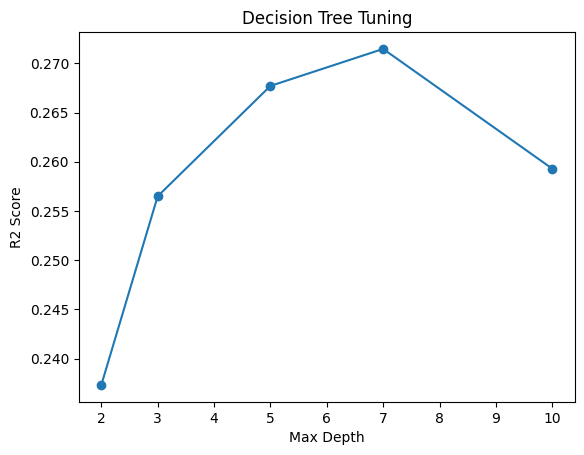

In [23]:
plt.plot(
    depths,
    dt_scores,
    marker='o'
)

plt.xlabel("Max Depth")
plt.ylabel("R2 Score")

plt.title("Decision Tree Tuning")

plt.show()

In [57]:
# Best Decision Tree Model

best_dt = DecisionTreeRegressor(
    
    max_depth = 7,
    random_state=42

)

best_dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",7
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [59]:
y_pred_dt = best_dt.predict(X_test)

In [60]:
dt_r2 = r2_score(
    y_test,
    y_pred_dt
)

dt_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred_dt
    )
)

dt_mae = mean_absolute_error(
    y_test,
    y_pred_dt
)

print("R2 Score:", dt_r2)

print("RMSE:", dt_rmse)

print("MAE:", dt_mae)

R2 Score: 0.2714580569860968
RMSE: 0.8534146528288715
MAE: 0.6262015966606396


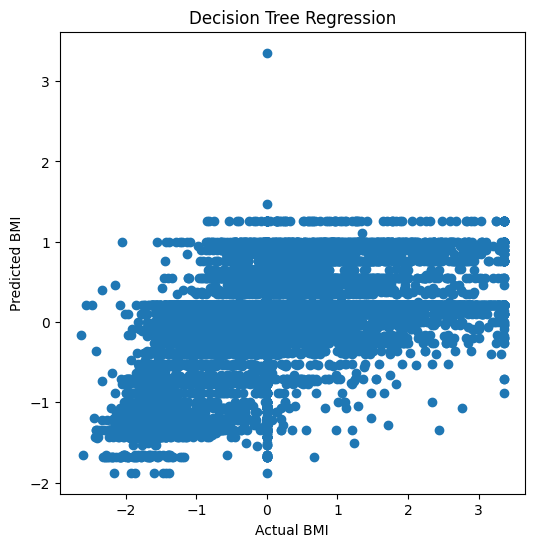

In [61]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_test,
    y_pred_dt
)

plt.xlabel("Actual BMI")

plt.ylabel("Predicted BMI")

plt.title("Decision Tree Regression")

plt.show()

RANDOM FOREST

In [51]:
estimators = [10, 50, 100, 200]

rf_scores = []

for n in estimators:

    rf = RandomForestRegressor(
        n_estimators=n,
        random_state=42
    )

    rf.fit(X_train, y_train)

    y_pred_dt = rf.predict(X_test)

    r2 = r2_score(y_test, y_pred_dt)

    rf_scores.append(r2)

    print("Estimators:", n, "R2:", r2)

Estimators: 10 R2: 0.03445165861184252
Estimators: 50 R2: 0.07841956859564458
Estimators: 100 R2: 0.08442056772119155
Estimators: 200 R2: 0.08717273021939664


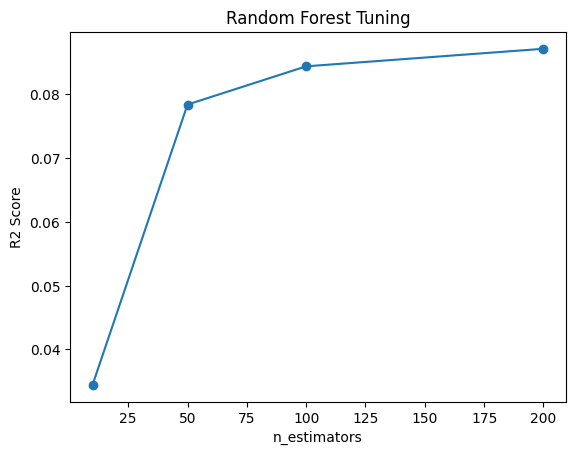

In [52]:
plt.plot(
    estimators,
    rf_scores,
    marker='o'
)

plt.xlabel("n_estimators")
plt.ylabel("R2 Score")

plt.title("Random Forest Tuning")

plt.show()

In [53]:
# BEST RANDOM FOREST MODEL

best_estimator = estimators[
    np.argmax(rf_scores)
]

best_rf = RandomForestRegressor(
    n_estimators=best_estimator,
    random_state=42
)

best_rf.fit(X_train, y_train)

y_pred_rf = best_rf.predict(X_test)

rf_r2 = r2_score(
    y_test,
    y_pred_rf
)

print(rf_r2)

0.08717273021939664


In [56]:
rf_rmse = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

rf_mae = mean_absolute_error(
    y_test,
    y_pred_rf
)
print("MAE : ",rf_mae)
print("RMSE : ",rf_rmse)

MAE :  0.7153841721617739
RMSE :  0.9552721539131818


In [26]:
importance = best_rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
})

importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

importance_df

,Feature,Importance
1,age,0.480889
6,blood_glucose_level,0.195152
5,HbA1c_level,0.185640
4,smoking_history,0.060591
7,diabetes,0.030191
0,gender,0.026120
2,hypertension,0.010808
3,heart_disease,0.010609


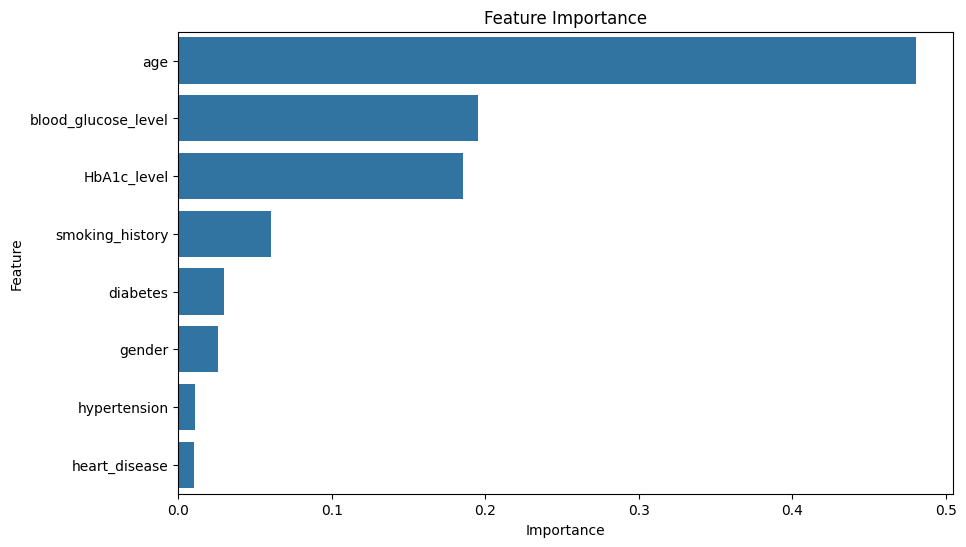

In [27]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df
)

plt.title("Feature Importance")

plt.show()

COMPARISON

In [65]:
results = pd.DataFrame({

    "Model": [

        "Multiple Linear Regression",
        "Polynomial Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Decision Tree Regression",
        "Random Forest Regression"

    ],

    "Best Hyperparameter": [

        "No Hyperparameter",
        f"degree = {best_degree}",
        f"alpha = {best_alpha_ridge}",
        f"alpha = {best_alpha_lasso}",
        f"max_depth = {7}",
        f"n_estimators = {best_estimator}"

    ],

    "R2 Score": [

        lr_r2,
        poly_r2,
        max(ridge_scores),
        max(lasso_scores),
        max(dt_scores),
        max(rf_scores)

    ],

    "RMSE": [

        lr_rmse,
        poly_rmse,
        ridge_rmse,
        lasso_rmse,
        dt_rmse,
        rf_rmse

    ],

    "MAE": [

        lr_mae,
        poly_mae,
        ridge_mae,
        lasso_mae,
        dt_mae,
        rf_mae

    ]

})

results

,Model,Best Hyperparameter,R2 Score,RMSE,MAE
0,Multiple Linear Regression,No Hyperparameter,0.143807,0.925164,0.689736
1,Polynomial Regression,degree = 3,0.272352,0.852891,0.626299
2,Ridge Regression,alpha = 100,0.143838,0.925147,0.689661
3,Lasso Regression,alpha = 0.001,0.143884,0.999930,0.693634
4,Decision Tree Regression,max_depth = 7,0.271458,0.853415,0.626202
5,Random Forest Regression,n_estimators = 200,0.087173,0.955272,0.715384


BEST MODEL

In [66]:
best_model = results.loc[
    results["R2 Score"].idxmax()
]

best_model

Model                  Polynomial Regression
Best Hyperparameter               degree = 3
R2 Score                            0.272352
RMSE                                0.852891
MAE                                 0.626299
Name: 1, dtype: object

In [67]:
# SAVING BEST MODEL

In [68]:
import joblib

In [71]:
# saving polynomial transformer
joblib.dump(
    best_poly,
    "E:\ml assignment\diabetes_dataset_prediction\models/polynomial_transformer.pkl"
)

<>:4: SyntaxWarning: invalid escape sequence '\m'
<>:4: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Samya\AppData\Local\Temp\ipykernel_23180\1646252291.py:4: SyntaxWarning: invalid escape sequence '\m'
  "E:\ml assignment\diabetes_dataset_prediction\models/polynomial_transformer.pkl"


['E:\\ml assignment\\diabetes_dataset_prediction\\models/polynomial_transformer.pkl']

In [72]:
joblib.dump(
    final_poly_model,
    "E:\ml assignment\diabetes_dataset_prediction\models/best_polynomial_model.pkl"
)

<>:3: SyntaxWarning: invalid escape sequence '\m'
<>:3: SyntaxWarning: invalid escape sequence '\m'
C:\Users\Samya\AppData\Local\Temp\ipykernel_23180\699037423.py:3: SyntaxWarning: invalid escape sequence '\m'
  "E:\ml assignment\diabetes_dataset_prediction\models/best_polynomial_model.pkl"


['E:\\ml assignment\\diabetes_dataset_prediction\\models/best_polynomial_model.pkl']